In [ ]:
!pip install -U keras-cv tensorflow


In [ ]:
!pip install -U efficientnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.7 MB/s eta 0:00:00


In [ ]:
!pip install keras-cv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 33.9 MB/s eta 0:00:00


In [ ]:
!pip install   scikit-optimize optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 22.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


# ===============================
# 2. Imports
# ===============================
import os
import random
import shutil
from PIL import Image, ImageEnhance
from tqdm import tqdm

# ===============================
# 3. Paths & Config
# ===============================
SOURCE_ROOT = "/content/drive/MyDrive/Journals/Chemical_images/Data/kaggle"
DEST_ROOT = "/content/drive/MyDrive/Journals/Chemical_images/Data/Preprocessed"

CLASSES = {
    "one_molecule": "one",
    "reactions": "reactions",
    "several_molecules": "several"
}

IMG_SIZE = (250, 250)
JPEG_QUALITY = 70  # Compression level
RANDOM_SEED = 42

TRAIN_SPLIT = 0.70
TEST_SPLIT = 0.15
VAL_SPLIT = 0.15

random.seed(RANDOM_SEED)

# ===============================
# 4. Create Folder Structure
# ===============================
for split in ["train", "test", "validation"]:
    for cls in CLASSES.keys():
        os.makedirs(os.path.join(DEST_ROOT, split, cls), exist_ok=True)

# ===============================
# 5. Augmentation Functions
# ===============================
def augment_image(img):
    aug_type = random.choice([
        "rotate_90",
        "rotate_180",
        "flip_h",
        "flip_v",
        "brightness",
        "contrast"
    ])

    if aug_type == "rotate_90":
        return img.rotate(90, expand=True)
    elif aug_type == "rotate_180":
        return img.rotate(180, expand=True)
    elif aug_type == "flip_h":
        return img.transpose(Image.FLIP_LEFT_RIGHT)
    elif aug_type == "flip_v":
        return img.transpose(Image.FLIP_TOP_BOTTOM)
    elif aug_type == "brightness":
        enhancer = ImageEnhance.Brightness(img)
        return enhancer.enhance(random.uniform(0.6, 1.4))
    elif aug_type == "contrast":
        enhancer = ImageEnhance.Contrast(img)
        return enhancer.enhance(random.uniform(0.6, 1.4))

# ===============================
# 6. Process Each Class
# ===============================
for cls_name, prefix in CLASSES.items():
    print(f"\nProcessing class: {cls_name}")

    src_dir = os.path.join(SOURCE_ROOT, cls_name)
    all_images = [
        f for f in os.listdir(src_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'))
    ]

    random.shuffle(all_images)

    processed_images = []

    # ---- Original + Augmented ----
    counter = 1
    for img_name in tqdm(all_images):
        img_path = os.path.join(src_dir, img_name)

        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize(IMG_SIZE)

            # Save original
            processed_images.append((img.copy(), f"{prefix}_{counter}.jpeg"))
            counter += 1

            # Save augmented (1 per image)
            aug_img = augment_image(img)
            aug_img = aug_img.resize(IMG_SIZE)
            processed_images.append((aug_img.copy(), f"{prefix}_{counter}.jpeg"))
            counter += 1

        except Exception as e:
            print(f"Skipping {img_name}: {e}")

    # ===============================
    # 7. Train / Test / Validation Split
    # ===============================
    total = len(processed_images)
    train_end = int(TRAIN_SPLIT * total)
    test_end = train_end + int(TEST_SPLIT * total)

    splits = {
        "train": processed_images[:train_end],
        "test": processed_images[train_end:test_end],
        "validation": processed_images[test_end:]
    }

    # ===============================
    # 8. Save Images (Compressed JPEG)
    # ===============================
    for split, items in splits.items():
        save_dir = os.path.join(DEST_ROOT, split, cls_name)

        for img, name in tqdm(items, desc=f"Saving {split}/{cls_name}"):
            save_path = os.path.join(save_dir, name)
            img.save(save_path, "JPEG", quality=JPEG_QUALITY, optimize=True)

print("\n✅ PREPROCESSING COMPLETE!")
print("Dataset saved at:")
print(DEST_ROOT)



Processing class: one_molecule


Saving validation/one_molecule: 100%|██████████| 1200/1200 [00:10<00:00, 110.28it/s]



Processing class: reactions


Saving validation/reactions: 100%|██████████| 1200/1200 [00:10<00:00, 114.95it/s]



Processing class: several_molecules


Saving validation/several_molecules: 100%|██████████| 1200/1200 [00:10<00:00, 111.61it/s]


✅ PREPROCESSING COMPLETE!
Dataset saved at:
/content/drive/MyDrive/Journals/Chemical_images/Data/Preprocessed


CHEMICAL IMAGE CLASSIFICATION – BASELINE DL MODELS
Classes: ['one_molecule', 'reactions', 'several_molecules']
Found 16800 images belonging to 3 classes.
Found 3600 images belonging to 3 classes.
Found 3600 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

TRAINING MobileNetV2
Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 176s 280ms/step - accuracy: 0.7316 - loss: 0.6543 - val_accuracy: 0.8914 - val_loss: 0.2932
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 89s 169ms/step - accuracy: 0.8808 - loss: 0.3166 - val_accuracy: 0.9083 - val_loss: 0.2439
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 87s 166ms/step - accuracy: 0.9021 - loss: 0.2620 - val_accuracy: 0.9208 - val_loss: 0.2173
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 88s 168ms/step - accuracy: 0.9190 - loss: 0.2222 - val_accuracy: 0.9222 - val_loss: 0.2082
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 86s 164ms/step - accuracy: 0.9344 - loss: 0.1876 - val_accuracy: 0.9283 - val_loss: 0.1956
Epoch 6/20
525/525 ━━━━━━━━━━━━━━━━

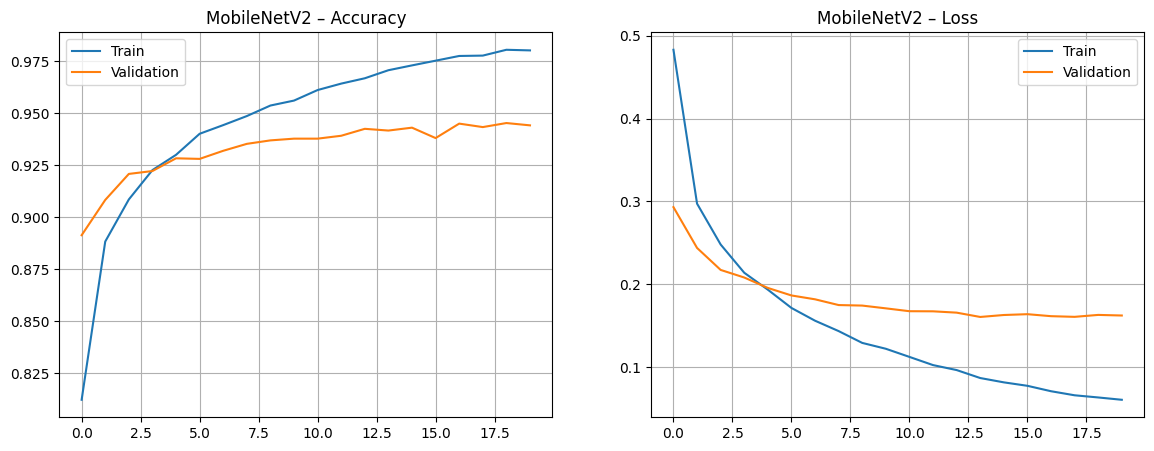

113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 168ms/step

CLASSIFICATION REPORT – MobileNetV2
                   precision    recall  f1-score   support

     one_molecule       0.95      0.96      0.95      1200
        reactions       0.91      0.94      0.93      1200
several_molecules       0.95      0.92      0.93      1200

         accuracy                           0.94      3600
        macro avg       0.94      0.94      0.94      3600
     weighted avg       0.94      0.94      0.94      3600



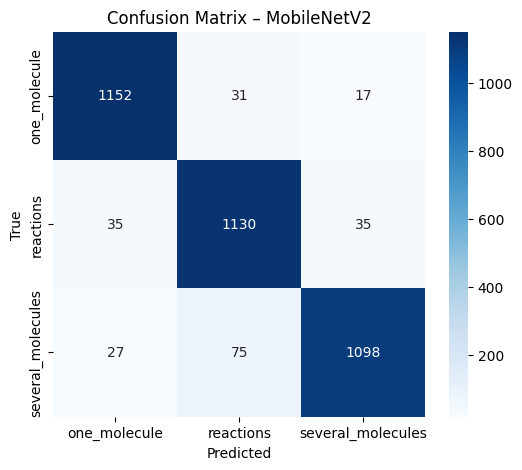

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

TRAINING ResNet50
Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 131s 223ms/step - accuracy: 0.5126 - loss: 0.9923 - val_accuracy: 0.6983 - val_loss: 0.7314
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 89s 170ms/step - accuracy: 0.6644 - loss: 0.7591 - val_accuracy: 0.6947 - val_loss: 0.6870
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 88s 168ms/step - accuracy: 0.6876 - loss: 0.7087 - val_accuracy: 0.7169 - val_loss: 0.6649
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 88s 167ms/step - accuracy: 0.7122 - loss: 0.6782 - val_accuracy: 0.7486 - val_loss: 0.6276
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 88s 167ms/step - accuracy: 0.7192 - loss: 0.6544 - val_accuracy: 0.7511 - val_loss: 0.6047
Epoch 6/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 88s 167ms/step - accuracy: 0.7393 - loss: 0.6266 - val_accuracy: 0.7669 - val_loss: 0.5954
Epoch 7/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 87s 165ms/step - accuracy: 0.7334 - loss: 0.6288 - val_accuracy: 0.7717 - val_loss: 0.5801
Epoch 8/20
5

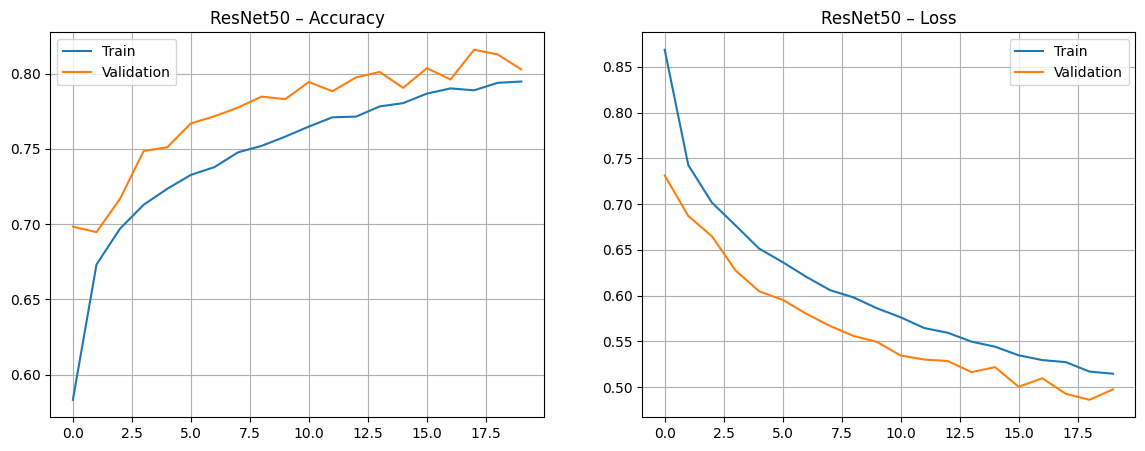

113/113 ━━━━━━━━━━━━━━━━━━━━ 23s 167ms/step

CLASSIFICATION REPORT – ResNet50
                   precision    recall  f1-score   support

     one_molecule       0.92      0.83      0.87      1200
        reactions       0.67      0.85      0.75      1200
several_molecules       0.85      0.71      0.77      1200

         accuracy                           0.80      3600
        macro avg       0.81      0.80      0.80      3600
     weighted avg       0.81      0.80      0.80      3600



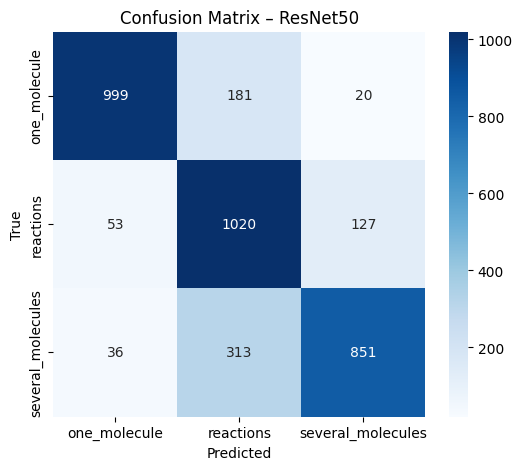

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

TRAINING EfficientNetB0
Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 126s 194ms/step - accuracy: 0.3434 - loss: 1.1084 - val_accuracy: 0.3722 - val_loss: 1.0942
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 87s 165ms/step - accuracy: 0.3580 - loss: 1.0957 - val_accuracy: 0.3675 - val_loss: 1.0928
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 141s 162ms/step - accuracy: 0.3707 - loss: 1.0932 - val_accuracy: 0.4258 - val_loss: 1.0889
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 86s 163ms/step - accuracy: 0.3798 - loss: 1.0909 - val_accuracy: 0.4392 - val_loss: 1.0871
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 85s 161ms/step - accuracy: 0.3742 - loss: 1.0907 - val_accuracy: 0.3967 - val_loss: 1.0849
Epoch 6/20
126/525 ━━━━━━━━━━━━━━━━━━━━ 1:12 182ms/step - accuracy: 0.3856 - loss: 1.0887

KeyboardInterrupt: 

In [ ]:
# =============================================================================
# CHEMICAL IMAGE CLASSIFICATION – 4 PRETRAINED BASELINE MODELS
# =============================================================================

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras_cv

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURATION
# =============================================================================
BASE_DIR = "/content/drive/MyDrive/Journals/Chemical_images/Data/Preprocessed"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
VAL_DIR   = os.path.join(BASE_DIR, "validation")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print("="*90)
print("CHEMICAL IMAGE CLASSIFICATION – BASELINE DL MODELS")
print("Classes:", CLASS_NAMES)
print("="*90)

# =============================================================================
# DATA GENERATORS
# =============================================================================
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

test_gen = datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

val_gen = datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def plot_history(history, model_name):
    fig, ax = plt.subplots(1,2, figsize=(14,5))

    ax[0].plot(history.history['accuracy'], label='Train')
    ax[0].plot(history.history['val_accuracy'], label='Validation')
    ax[0].set_title(f"{model_name} – Accuracy")
    ax[0].legend(); ax[0].grid()

    ax[1].plot(history.history['loss'], label='Train')
    ax[1].plot(history.history['val_loss'], label='Validation')
    ax[1].set_title(f"{model_name} – Loss")
    ax[1].legend(); ax[1].grid()

    plt.show()

def evaluate_model(model, model_name):
    preds = model.predict(val_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_gen.classes

    print("\n", "="*80)
    print(f"CLASSIFICATION REPORT – {model_name}")
    print("="*80)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

# =============================================================================
# MODEL BUILDERS
# =============================================================================
def build_transfer_model(base_model):
    base_model.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)
    return Model(base_model.input, out)

# =============================================================================
# TRAINING PIPELINE
# =============================================================================
results = []

def train_and_evaluate(model, model_name):
    print("\n", "="*90)
    print(f"TRAINING {model_name}")
    print("="*90)

    start = time.time()
    history = model.fit(
        train_gen,
        validation_data=test_gen,
        epochs=EPOCHS,
        verbose=1
    )
    duration = time.time() - start

    plot_history(history, model_name)

    report = evaluate_model(model, model_name)

    results.append({
        "Model": model_name,
        "Parameters": model.count_params(),
        "Train_Accuracy": history.history['accuracy'][-1],
        "Test_Accuracy": history.history['val_accuracy'][-1],
        "Train_Loss": history.history['loss'][-1],
        "Test_Loss": history.history['val_loss'][-1],
        "Training_Time_sec": duration,
        "Precision": report['weighted avg']['precision'],
        "Recall": report['weighted avg']['recall'],
        "F1-Score": report['weighted avg']['f1-score']
    })

# =============================================================================
# MODEL 1 – MobileNetV2
# =============================================================================
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
model = build_transfer_model(base)
model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
train_and_evaluate(model, "MobileNetV2")

# =============================================================================
# MODEL 2 – ResNet50
# =============================================================================
from tensorflow.keras.applications import ResNet50

base = ResNet50(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
model = build_transfer_model(base)
model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
train_and_evaluate(model, "ResNet50")

# =============================================================================
# MODEL 3 – EfficientNetB0
# =============================================================================
from tensorflow.keras.applications import EfficientNetB0

base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
model = build_transfer_model(base)
model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
train_and_evaluate(model, "EfficientNetB0")

# =============================================================================
# MODEL 4 – Vision Transformer (ViT-B/16)
# =============================================================================
vit = keras_cv.models.ViTClassifier(
    input_shape=(*IMG_SIZE,3),
    num_classes=NUM_CLASSES,
    patch_size=16,
    transformer_layers=12,
    num_heads=12,
    hidden_dim=768,
    mlp_dim=3072,
    dropout=0.1
)

vit.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

train_and_evaluate(vit, "ViT-B/16")

# =============================================================================
# SAVE RESULTS
# =============================================================================
df = pd.DataFrame(results)
csv_path = os.path.join(BASE_DIR, "baseline_model_results.csv")
df.to_csv(csv_path, index=False)

print("\n", "="*90)
print("FINAL RESULTS")
print(df)
print("\nSaved to:", csv_path)
print("="*90)
print("✅ ALL MODELS COMPLETED SUCCESSFULLY")


CHEMICAL IMAGE CLASSIFICATION – BASELINE DL MODELS
Classes: ['one_molecule', 'reactions', 'several_molecules']
Found 16800 images belonging to 3 classes.
Found 3600 images belonging to 3 classes.
Found 3600 images belonging to 3 classes.
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

TRAINING EfficientNetB3
Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 183s 231ms/step - accuracy: 0.4295 - loss: 1.0441 - val_accuracy: 0.5000 - val_loss: 0.9518
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 86s 163ms/step - accuracy: 0.4760 - loss: 0.9806 - val_accuracy: 0.5158 - val_loss: 0.9411
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 88s 167ms/step - accuracy: 0.4772 - loss: 0.9757 - val_accuracy: 0.5122 - val_loss: 0.9376
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 86s 164ms/step - accuracy: 0.4855 - loss: 0.9786 - val_accuracy: 0.5167 - val_loss: 0.9307
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 88s 168ms/step - accuracy: 0.4870 - loss: 0.9680 - val_accuracy: 0.5192 - val_loss: 0.9318
Epoch 6/20
525/525 ━━━━━━━━━━━

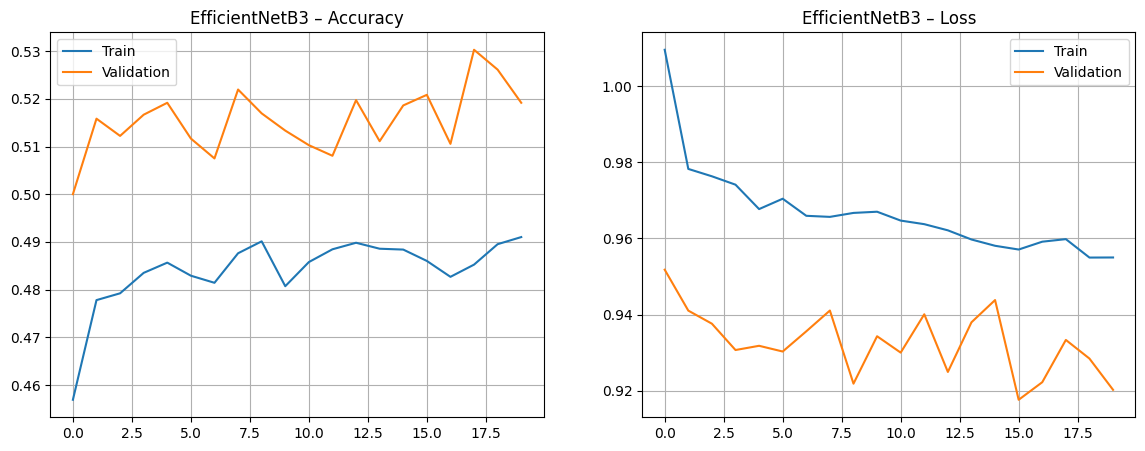

113/113 ━━━━━━━━━━━━━━━━━━━━ 36s 230ms/step

CLASSIFICATION REPORT – EfficientNetB3
                   precision    recall  f1-score   support

     one_molecule       0.66      0.56      0.61      1200
        reactions       0.31      0.15      0.20      1200
several_molecules       0.47      0.79      0.59      1200

         accuracy                           0.50      3600
        macro avg       0.48      0.50      0.47      3600
     weighted avg       0.48      0.50      0.47      3600



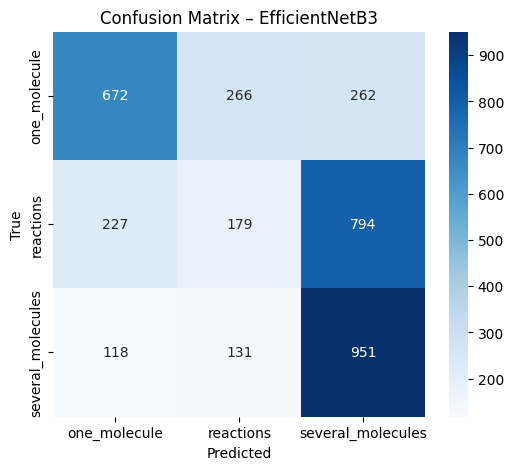

AttributeError: module 'keras_cv.api.models' has no attribute 'ViTClassifier'

In [ ]:
# =============================================================================
# CHEMICAL IMAGE CLASSIFICATION – 4 PRETRAINED BASELINE MODELS
# =============================================================================

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras_cv

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURATION
# =============================================================================
BASE_DIR = "/content/drive/MyDrive/Journals/Chemical_images/Data/Preprocessed"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
VAL_DIR   = os.path.join(BASE_DIR, "validation")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print("="*90)
print("CHEMICAL IMAGE CLASSIFICATION – BASELINE DL MODELS")
print("Classes:", CLASS_NAMES)
print("="*90)

# =============================================================================
# DATA GENERATORS
# =============================================================================
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

test_gen = datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

val_gen = datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def plot_history(history, model_name):
    fig, ax = plt.subplots(1,2, figsize=(14,5))

    ax[0].plot(history.history['accuracy'], label='Train')
    ax[0].plot(history.history['val_accuracy'], label='Validation')
    ax[0].set_title(f"{model_name} – Accuracy")
    ax[0].legend(); ax[0].grid()

    ax[1].plot(history.history['loss'], label='Train')
    ax[1].plot(history.history['val_loss'], label='Validation')
    ax[1].set_title(f"{model_name} – Loss")
    ax[1].legend(); ax[1].grid()

    plt.show()

def evaluate_model(model, model_name):
    preds = model.predict(val_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_gen.classes

    print("\n", "="*80)
    print(f"CLASSIFICATION REPORT – {model_name}")
    print("="*80)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

# =============================================================================
# MODEL BUILDERS
# =============================================================================
def build_transfer_model(base_model):
    base_model.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)
    return Model(base_model.input, out)

# =============================================================================
# TRAINING PIPELINE
# =============================================================================
results = []

def train_and_evaluate(model, model_name):
    print("\n", "="*90)
    print(f"TRAINING {model_name}")
    print("="*90)

    start = time.time()
    history = model.fit(
        train_gen,
        validation_data=test_gen,
        epochs=EPOCHS,
        verbose=1
    )
    duration = time.time() - start

    plot_history(history, model_name)

    report = evaluate_model(model, model_name)

    results.append({
        "Model": model_name,
        "Parameters": model.count_params(),
        "Train_Accuracy": history.history['accuracy'][-1],
        "Test_Accuracy": history.history['val_accuracy'][-1],
        "Train_Loss": history.history['loss'][-1],
        "Test_Loss": history.history['val_loss'][-1],
        "Training_Time_sec": duration,
        "Precision": report['weighted avg']['precision'],
        "Recall": report['weighted avg']['recall'],
        "F1-Score": report['weighted avg']['f1-score']
    })



# =============================================================================
# MODEL 3 – EfficientNetB3
# =============================================================================
from tensorflow.keras.applications import EfficientNetB3

base = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

model = build_transfer_model(base)
model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

train_and_evaluate(model, "EfficientNetB3")


# =============================================================================
# SAVE RESULTS
# =============================================================================
df = pd.DataFrame(results)
csv_path = os.path.join(BASE_DIR, "baseline_model_results.csv")
df.to_csv(csv_path, index=False)

print("\n", "="*90)
print("FINAL RESULTS")
print(df)
print("\nSaved to:", csv_path)
print("="*90)
print("✅ ALL MODELS COMPLETED SUCCESSFULLY")


In [ ]:
print(keras_cv.models.ImageClassifier.presets.keys())

dict_keys(['resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'resnet18_v2', 'resnet34_v2', 'resnet50_v2', 'resnet101_v2', 'resnet152_v2', 'mobilenet_v3_small', 'mobilenet_v3_large', 'csp_darknet_tiny', 'csp_darknet_s', 'csp_darknet_m', 'csp_darknet_l', 'csp_darknet_xl', 'efficientnetv1_b0', 'efficientnetv1_b1', 'efficientnetv1_b2', 'efficientnetv1_b3', 'efficientnetv1_b4', 'efficientnetv1_b5', 'efficientnetv1_b6', 'efficientnetv1_b7', 'efficientnetv2_s', 'efficientnetv2_m', 'efficientnetv2_l', 'efficientnetv2_b0', 'efficientnetv2_b1', 'efficientnetv2_b2', 'efficientnetv2_b3', 'densenet121', 'densenet169', 'densenet201', 'efficientnetlite_b0', 'efficientnetlite_b1', 'efficientnetlite_b2', 'efficientnetlite_b3', 'efficientnetlite_b4', 'yolo_v8_xs_backbone', 'yolo_v8_s_backbone', 'yolo_v8_m_backbone', 'yolo_v8_l_backbone', 'yolo_v8_xl_backbone', 'vitdet_base', 'vitdet_large', 'vitdet_huge', 'videoswin_tiny', 'videoswin_small', 'videoswin_base', 'resnet50_imagenet', 'resnet50_v